In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
gdp_raw = pd.read_excel("C:/Users/sanch/OneDrive/Documents/gdp.xlsx.xlsx", 
                         sheet_name = "Data",
                         skiprows=3)

In [2]:
gdp = gdp_raw[["Country Name", "Country Code", "2022"]].copy()
gdp.columns = ["country", "code", "gdp_per_capita"]
gdp = gdp.dropna(subset=["gdp_per_capita"])

In [3]:
print(gdp.head())

                       country code  gdp_per_capita
0                        Aruba  ABW    30975.998912
1  Africa Eastern and Southern  AFE     1679.327622
2                  Afghanistan  AFG      357.261153
3   Africa Western and Central  AFW     2138.473153
4                       Angola  AGO     3682.113151


In [4]:
hdi_raw = pd.read_excel("C:/Users/sanch/OneDrive/Documents/hdi.xlsx.xlsx",
                         sheet_name="Table 1. HDI",
                         skiprows=6)

In [5]:
hdi = hdi_raw.iloc[:, [1, 2]].copy()
hdi.columns = ["country", "hdi"]
hdi = hdi.dropna(subset=["hdi", "country"])
hdi["hdi"] = pd.to_numeric(hdi["hdi"], errors="coerce")
hdi = hdi.dropna(subset=["hdi"])

In [6]:
print(hdi.head())

       country    hdi
1      Iceland  0.972
2       Norway  0.970
3  Switzerland  0.970
4      Denmark  0.962
5      Germany  0.959


In [7]:
merged = pd.merge(gdp, hdi, on="country")

print(merged.head())
print(f"Total countries: {len(merged)}")

                country code  gdp_per_capita    hdi
0           Afghanistan  AFG      357.261153  0.496
1                Angola  AGO     3682.113151  0.616
2               Albania  ALB     7756.961887  0.810
3               Andorra  AND    42414.047986  0.913
4  United Arab Emirates  ARE    50759.758923  0.940
Total countries: 168


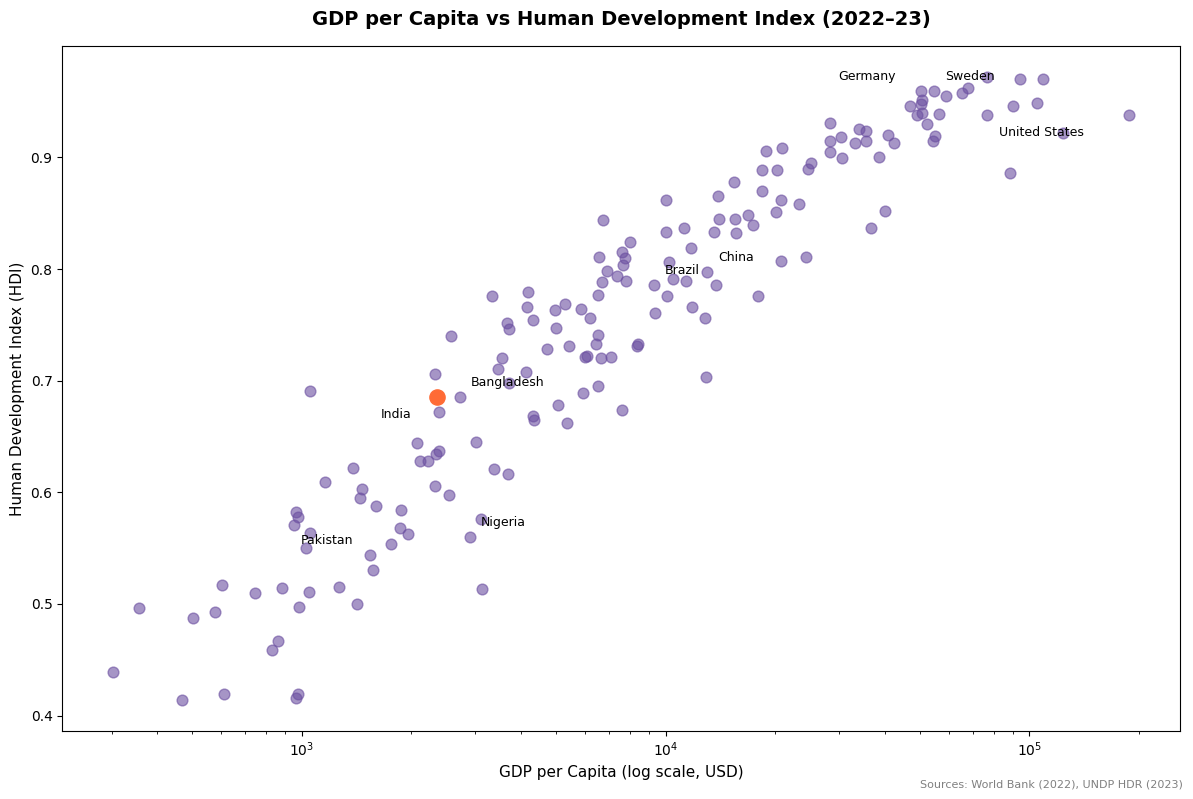

plot saved!!


In [9]:
highlight = ["India", "China", "United States", 
             "Bangladesh", "Nigeria", "Germany", 
             "Sweden", "Brazil", "Pakistan"]

plt.figure(figsize=(12, 8))

plt.scatter(merged["gdp_per_capita"], 
            merged["hdi"],
            color="#6b4fa0", 
            alpha=0.6, 
            s=60)

india = merged[merged["country"] == "India"]
plt.scatter(india["gdp_per_capita"], 
            india["hdi"],
            color="#ff6b35", 
            s=120,
            zorder=5)

offsets = {
    "India": (-40, -15),
    "Bangladesh": (8, 8),
    "Germany": (-60, 8),
    "Sweden": (8, 8),
    "United States": (8, -15),
    "China": (8, 8),
    "Brazil": (8, 8),
    "Pakistan": (-50, 8),
    "Nigeria": (8, 8),
}

for _, row in merged[merged["country"].isin(highlight)].iterrows():
    ox, oy = offsets.get(row["country"], (5, 8))
    plt.annotate(row["country"],
                xy=(row["gdp_per_capita"], row["hdi"]),
                xytext=(ox, oy),
                textcoords="offset points",
                fontsize=9)

plt.xscale("log")

plt.title("GDP per Capita vs Human Development Index (2022–23)", 
          fontsize=14, fontweight="bold", pad=15)
plt.xlabel("GDP per Capita (log scale, USD)", fontsize=11)
plt.ylabel("Human Development Index (HDI)", fontsize=11)
plt.figtext(0.99, 0.01, 
            "Sources: World Bank (2022), UNDP HDR (2023)",
            ha="right", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("gdp_vs_hdi_python.png", dpi=300, bbox_inches="tight")
plt.show()

print("plot saved!!")

# GDP per Capita vs Human Development Index
## A Cross-Country Analysis (2022–23)

**Data Sources:** World Bank (2022), UNDP HDR (2023)  
**Tools:** Python, pandas, matplotlib

## Key Findings
- Strong positive relationship between GDP and HDI globally
- India underperforms relative to its GDP level
- Bangladesh achieves comparable HDI to India at lower GDP
- Nordic countries show HDI gains flatten beyond ~$40,000 GDP per capita
- The log scale relationship suggests diminishing returns to income